In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
from google.colab import drive

# --- 1. Mount Drive ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# --- 2. Define ALL paths explicitly in this cell ---
PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
LOCAL_DIR = '/content/data'

# --- 3. Verify the zips are actually there ---
print("Checking Drive contents...")
if not os.path.exists(PROJECT_DIR):
    print(f"❌ Folder not found: {PROJECT_DIR}")
    print("   Please check the exact name of your folder in Drive.")
else:
    files_in_project = os.listdir(PROJECT_DIR)
    print(f"✅ Found folder. Contents:")
    for f in files_in_project:
        print(f"   -> {f}")

# --- 4. Create local dirs ---
os.makedirs(os.path.join(LOCAL_DIR, 'PlantVillage'), exist_ok=True)
os.makedirs(os.path.join(LOCAL_DIR, 'PlantDoc'), exist_ok=True)

# --- 5. Unzip to local disk ---
PV_ZIP = os.path.join(PROJECT_DIR, 'plantvillage-dataset.zip')
PD_ZIP = os.path.join(PROJECT_DIR, 'PlantDoc-Dataset-master.zip')

print(f"\nUnzipping PlantVillage from: {PV_ZIP}")
!unzip -q "$PV_ZIP" -d "$LOCAL_DIR/PlantVillage"

print(f"\nUnzipping PlantDoc from: {PD_ZIP}")
!unzip -q "$PD_ZIP" -d "$LOCAL_DIR/PlantDoc"

print("\n✅ Unzipping complete!")

Checking Drive contents...
✅ Found folder. Contents:
   -> plantvillage-dataset.zip
   -> PlantDoc-Dataset-master.zip
   -> PlantVillage
   -> PlantDoc
   -> results

Unzipping PlantVillage from: /content/drive/MyDrive/PlantDiseaseProject/plantvillage-dataset.zip

Unzipping PlantDoc from: /content/drive/MyDrive/PlantDiseaseProject/PlantDoc-Dataset-master.zip

✅ Unzipping complete!


In [6]:
import os
import shutil

LOCAL_DIR = '/content/data'
PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'

# --- 1. Flatten PlantVillage ---
pv_nested = os.path.join(LOCAL_DIR, 'PlantVillage', 'plantvillage dataset')
if os.path.exists(pv_nested):
    print("Fixing PlantVillage nesting...")

    color_path = os.path.join(pv_nested, 'color')
    source_path = color_path if os.path.exists(color_path) else pv_nested
    for item in os.listdir(source_path):
        shutil.move(os.path.join(source_path, item),
                    os.path.join(LOCAL_DIR, 'PlantVillage', item))
    print("✅ PlantVillage flattened!")
else:
    print("ℹ️ PlantVillage appears already flat.")

# --- 2. Flatten PlantDoc ---
pd_nested = os.path.join(LOCAL_DIR, 'PlantDoc', 'PlantDoc-Dataset-master')
if os.path.exists(pd_nested):
    print("Fixing PlantDoc nesting...")
    for item in os.listdir(pd_nested):
        shutil.move(os.path.join(pd_nested, item),
                    os.path.join(LOCAL_DIR, 'PlantDoc', item))
    print("✅ PlantDoc flattened!")
else:
    print("ℹ️ PlantDoc appears already flat.")

# --- 3. Verify ---
print("\n" + "="*50)
print("VERIFICATION")
print("="*50)

pv_dir = os.path.join(LOCAL_DIR, 'PlantVillage')
pv_classes = sorted([f for f in os.listdir(pv_dir) if os.path.isdir(os.path.join(pv_dir, f))])
print(f"\n📁 PlantVillage: {len(pv_classes)} classes")
print(f"   First 5: {pv_classes[:5]}")

pd_dir = os.path.join(LOCAL_DIR, 'PlantDoc')
pd_train = os.path.join(pd_dir, 'train')
if os.path.exists(pd_train):
    pd_classes = sorted([f for f in os.listdir(pd_train) if os.path.isdir(os.path.join(pd_train, f))])
    print(f"\n📁 PlantDoc: {len(pd_classes)} classes in 'train'")
    print(f"   First 5: {pd_classes[:5]}")
else:
    print(f"\n⚠️ PlantDoc structure: {os.listdir(pd_dir)}")

Fixing PlantVillage nesting...
✅ PlantVillage flattened!
Fixing PlantDoc nesting...
✅ PlantDoc flattened!

VERIFICATION

📁 PlantVillage: 39 classes
   First 5: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

📁 PlantDoc: 28 classes in 'train'
   First 5: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot']


Valid classes: 38
⚠️ Empty/stray folders (will ignore): ['plantvillage dataset']


/tmp/ipykernel_2488/1920156873.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Class', data=df_counts, palette='viridis')


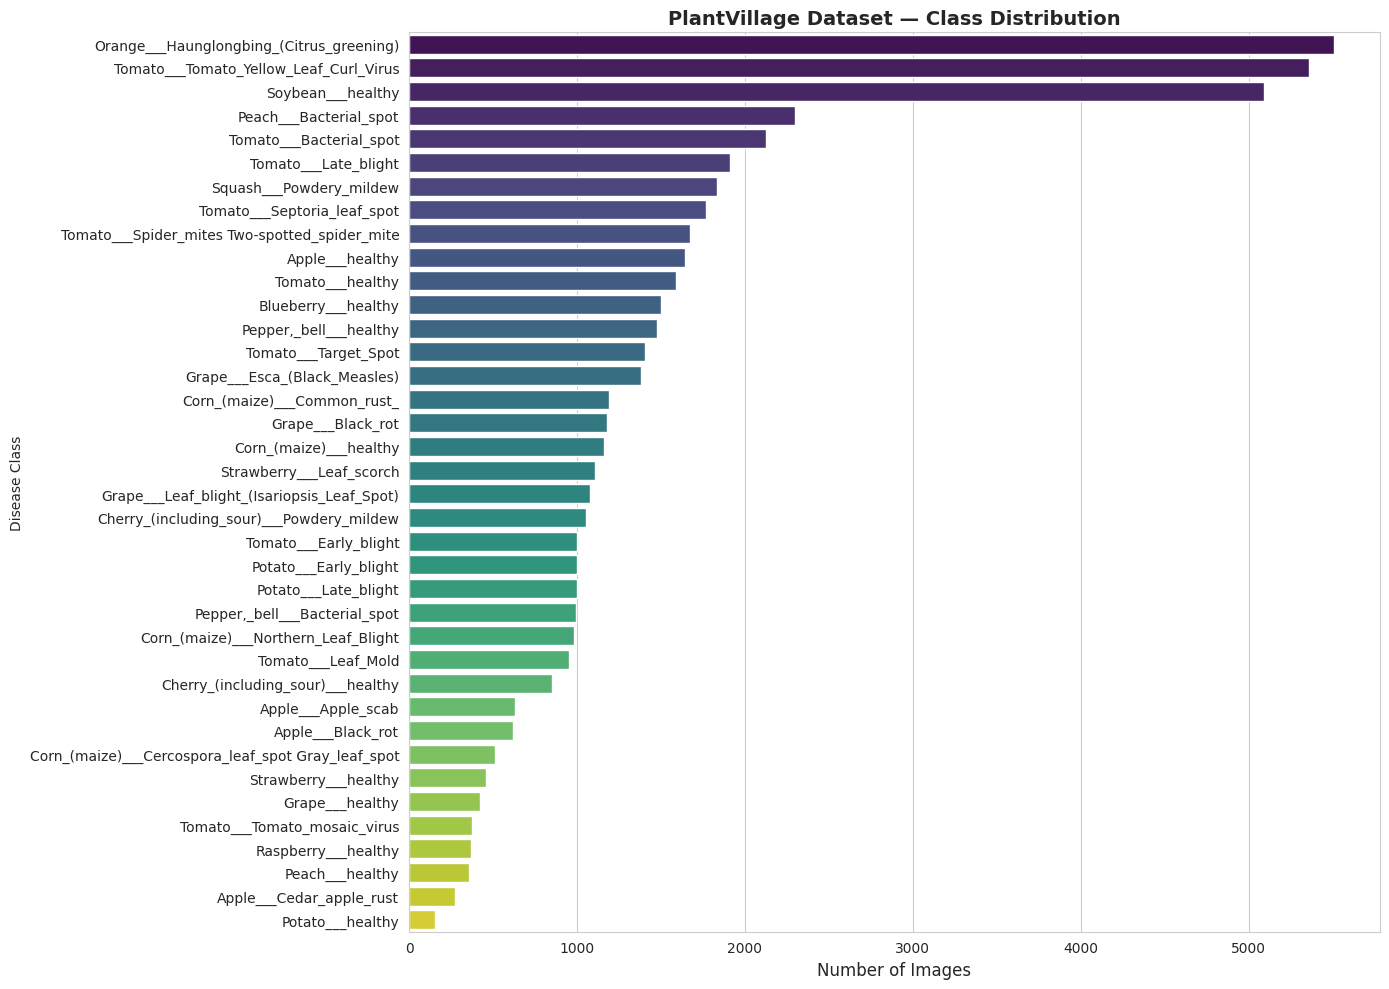


📊 Total images: 54,305
📊 Most frequent: Orange___Haunglongbing_(Citrus_greening) (5,507)
📊 Least frequent: Potato___healthy (152)
📊 Imbalance ratio: 36.2x


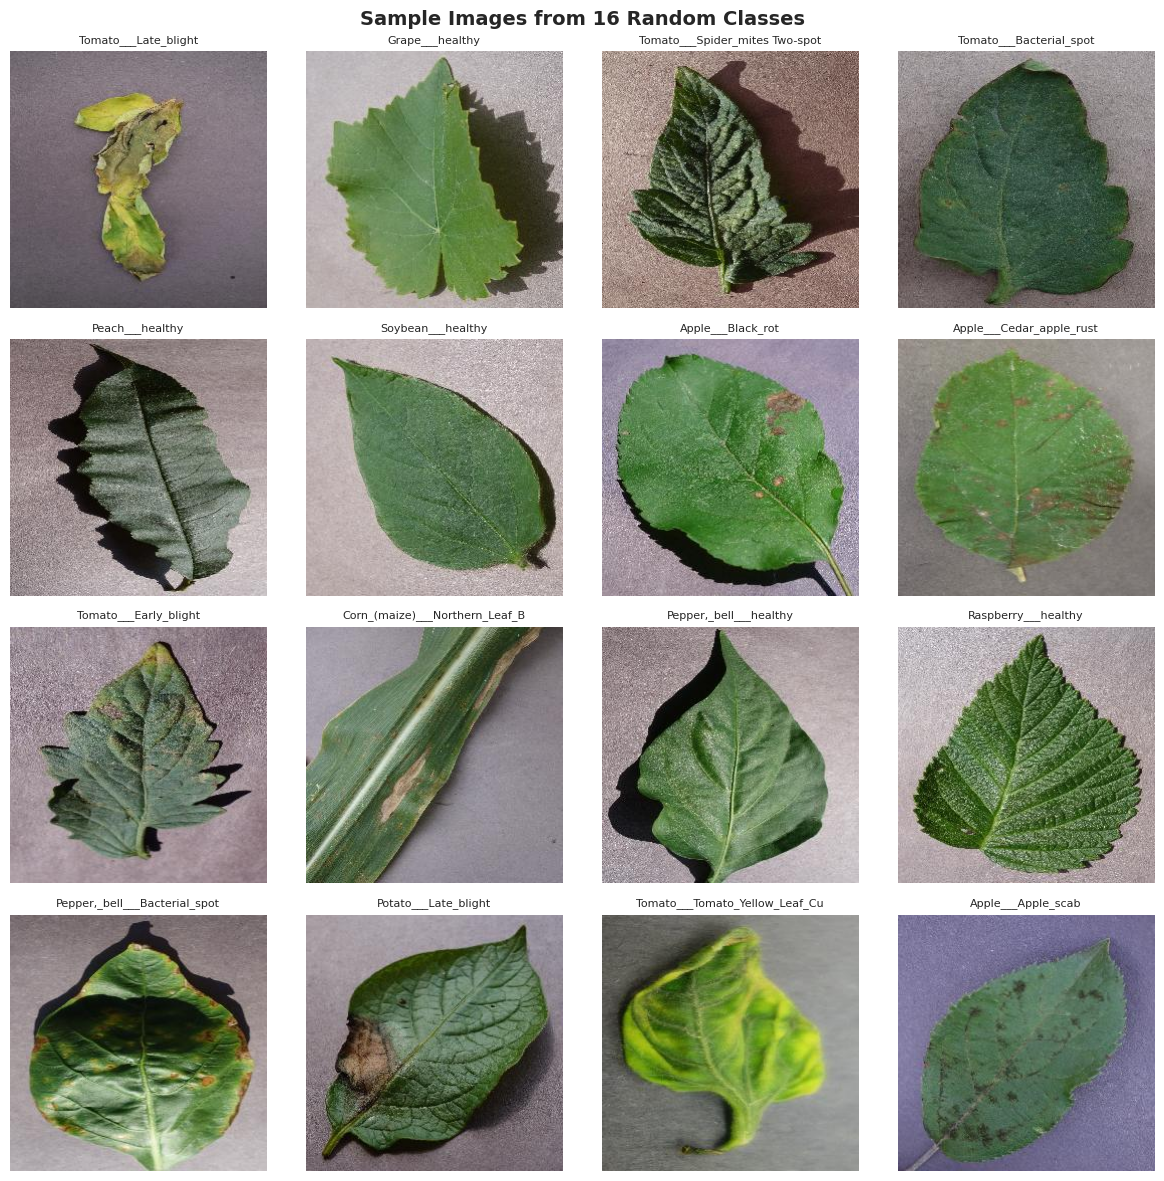


✅ Figures saved to: /content/drive/MyDrive/PlantDiseaseProject/results/figures


In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import random

LOCAL_DIR = '/content/data'
PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
FIG_DIR = os.path.join(PROJECT_DIR, 'results', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

pv_dir = os.path.join(LOCAL_DIR, 'PlantVillage')
sns.set_style("whitegrid")

# --- 1. Collect class distribution ---
class_counts = {}
corrupt_or_stray = []
for class_name in sorted(os.listdir(pv_dir)):
    class_path = os.path.join(pv_dir, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(images) > 0:
            class_counts[class_name] = len(images)
        else:
            corrupt_or_stray.append(class_name)

print(f"Valid classes: {len(class_counts)}")
if corrupt_or_stray:
    print(f"⚠️ Empty/stray folders (will ignore): {corrupt_or_stray}")

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False).reset_index(drop=True)

# --- 2. Save class distribution figure ---
plt.figure(figsize=(14, 10))
sns.barplot(x='Count', y='Class', data=df_counts, palette='viridis')
plt.title('PlantVillage Dataset — Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Disease Class', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Total images: {df_counts['Count'].sum():,}")
print(f"📊 Most frequent: {df_counts.iloc[0]['Class']} ({df_counts.iloc[0]['Count']:,})")
print(f"📊 Least frequent: {df_counts.iloc[-1]['Class']} ({df_counts.iloc[-1]['Count']:,})")
print(f"📊 Imbalance ratio: {df_counts['Count'].max() / df_counts['Count'].min():.1f}x")

# --- 3. Save sample image grid ---
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
sample_classes = random.sample(list(class_counts.keys()), 16)
for ax, cls in zip(axes.flatten(), sample_classes):
    cls_path = os.path.join(pv_dir, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_file))
    ax.imshow(img)
    ax.set_title(cls[:30], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Images from 16 Random Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Figures saved to: {FIG_DIR}")

In [8]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

LOCAL_DIR = '/content/data'
PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
SPLIT_DIR = os.path.join(PROJECT_DIR, 'results', 'splits')
os.makedirs(SPLIT_DIR, exist_ok=True)

pv_dir = os.path.join(LOCAL_DIR, 'PlantVillage')

# --- 1. Build a DataFrame of all images ---
rows = []
for class_name in sorted(os.listdir(pv_dir)):
    class_path = os.path.join(pv_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for img in os.listdir(class_path):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            rows.append({'filepath': os.path.join(class_path, img), 'label': class_name})

df = pd.DataFrame(rows)
print(f"Total images: {len(df):,} across {df['label'].nunique()} classes")

# --- 2. Stratified split: 80% train / 10% val / 10% test ---
train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")

# --- 3. Save label mapping + split CSVs to Drive ---
classes = sorted(df['label'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}

pd.DataFrame({'class': classes, 'index': range(len(classes))}).to_csv(
    os.path.join(SPLIT_DIR, 'class_names.csv'), index=False)
train_df.to_csv(os.path.join(SPLIT_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(SPLIT_DIR, 'val.csv'), index=False)
test_df.to_csv(os.path.join(SPLIT_DIR, 'test.csv'), index=False)

print(f"\n✅ Splits saved to: {SPLIT_DIR}")
print(f"✅ Class mapping saved ({len(classes)} classes)")

# --- 4. Sanity check: no overlap ---
train_paths = set(train_df['filepath'])
val_paths = set(val_df['filepath'])
test_paths = set(test_df['filepath'])
assert train_paths.isdisjoint(val_paths), "❌ Leakage: train/val overlap!"
assert train_paths.isdisjoint(test_paths), "❌ Leakage: train/test overlap!"
assert val_paths.isdisjoint(test_paths), "❌ Leakage: val/test overlap!"
print("✅ No data leakage detected between splits")

Total images: 54,305 across 38 classes

Split sizes:
  Train: 43,444 (80.0%)
  Val:   5,430 (10.0%)
  Test:  5,431 (10.0%)

✅ Splits saved to: /content/drive/MyDrive/PlantDiseaseProject/results/splits
✅ Class mapping saved (38 classes)
✅ No data leakage detected between splits


In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os

LOCAL_DIR = '/content/data'
PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
SPLIT_DIR = os.path.join(PROJECT_DIR, 'results', 'splits')
IMG_SIZE = 224
BATCH_SIZE = 32

def load_split_from_drive():
    train_df = pd.read_csv(os.path.join(SPLIT_DIR, 'train.csv'))
    val_df   = pd.read_csv(os.path.join(SPLIT_DIR, 'val.csv'))
    test_df  = pd.read_csv(os.path.join(SPLIT_DIR, 'test.csv'))
    class_df = pd.read_csv(os.path.join(SPLIT_DIR, 'class_names.csv'))
    class_to_idx = dict(zip(class_df['class'], class_df['index']))
    return train_df, val_df, test_df, class_to_idx

def decode_img(filepath, label, num_classes):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, num_classes)
    return img, label

def augment(img, label):
    """Augmentation with clipping to keep values in [0, 1]."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.12)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)   # <-- THE FIX
    return img, label

def make_dataset(df, class_to_idx, num_classes, training=False):
    paths = df['filepath'].values
    labels = np.array([class_to_idx[l] for l in df['label'].values], dtype=np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = ds.map(lambda p, l: decode_img(p, l, num_classes),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def get_all_datasets():
    train_df, val_df, test_df, class_to_idx = load_split_from_drive()
    num_classes = len(class_to_idx)
    train_ds = make_dataset(train_df, class_to_idx, num_classes, training=True)
    val_ds   = make_dataset(val_df,   class_to_idx, num_classes, training=False)
    test_ds  = make_dataset(test_df,  class_to_idx, num_classes, training=False)
    return train_ds, val_ds, test_ds, class_to_idx

# --- Test ---
train_ds, val_ds, test_ds, class_to_idx = get_all_datasets()
for imgs, labels in train_ds.take(1):
    print(f"✅ Image shape:  {imgs.shape}")
    print(f"✅ Label shape:  {labels.shape}")
    print(f"✅ Value range:  [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]  (should be [0.00, 1.00])")
print(f"✅ Batches — train:{len(train_ds)} val:{len(val_ds)} test:{len(test_ds)}")

✅ Image shape:  (32, 224, 224, 3)
✅ Label shape:  (32, 38)
✅ Value range:  [0.00, 1.00]  (should be [0.00, 1.00])
✅ Batches — train:1358 val:170 test:170


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os, time, json, matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
METRICS_DIR = os.path.join(RESULTS_DIR, 'metrics')
FIG_DIR = os.path.join(RESULTS_DIR, 'figures')
for d in [MODELS_DIR, METRICS_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Load data ---
train_ds, val_ds, test_ds, class_to_idx = get_all_datasets()
num_classes = len(class_to_idx)

# --- Build Custom CNN ---
def build_custom_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ])
    return model

model = build_custom_cnn(num_classes)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params = model.count_params()
print(f"\n✅ Model built. Total parameters: {total_params:,}")
print(f"   (Save this number — you'll need it for the comparison table)")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,030 (1.09 MB)

 Trainable params: 284,326 (1.08 MB)

 Non-trainable params: 704 (2.75 KB)


✅ Model built. Total parameters: 285,030
   (Save this number — you'll need it for the comparison table)


🚀 Starting training...

Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4935 - loss: 1.8116
Epoch 1: val_accuracy improved from None to 0.39853, saving model to /content/drive/MyDrive/PlantDiseaseProject/results/models/custom_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantDiseaseProject/results/models/custom_cnn.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 125s 78ms/step - accuracy: 0.6102 - loss: 1.3282 - val_accuracy: 0.3985 - val_loss: 2.3509 - learning_rate: 0.0010
Epoch 2/15
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7759 - loss: 0.7141
Epoch 2: val_accuracy improved from 0.39853 to 0.72136, saving model to /content/drive/MyDrive/PlantDiseaseProject/results/models/custom_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantDiseaseProject/results/models/custom_cnn.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 94s 69ms/step - accuracy: 0.8013 - loss: 0.6313 - val_accuracy: 0.7214 - val_loss: 0.8905 - learning_rate: 0.0

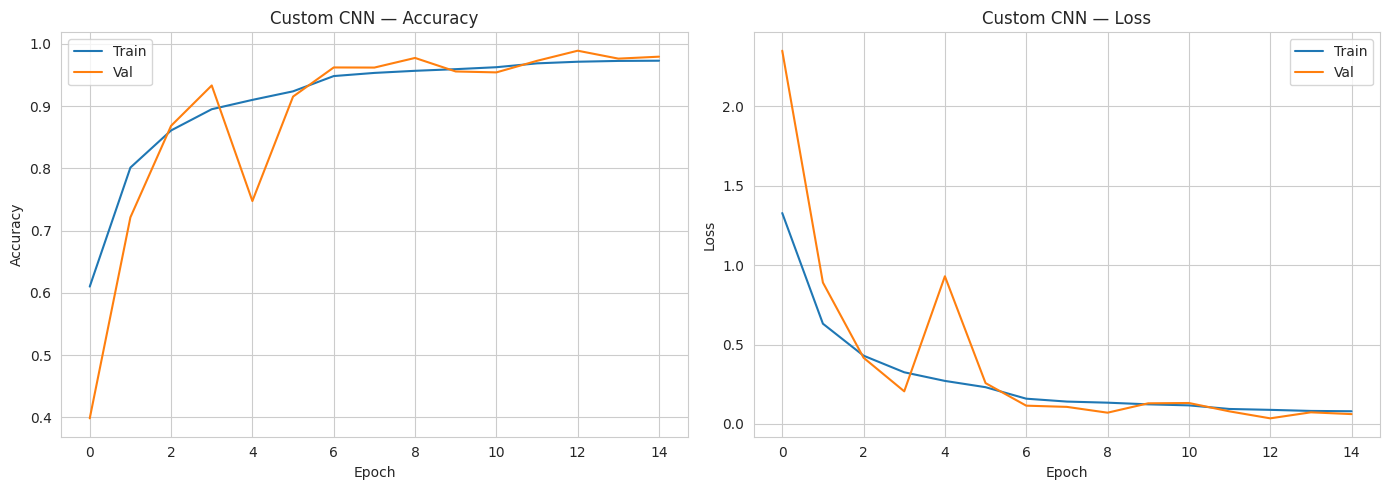


✅ Model:    /content/drive/MyDrive/PlantDiseaseProject/results/models/custom_cnn.keras
✅ History:  /content/drive/MyDrive/PlantDiseaseProject/results/metrics/custom_cnn_history.json
✅ Curves:   /content/drive/MyDrive/PlantDiseaseProject/results/figures/custom_cnn_curves.png

🎯 Best val accuracy: 98.90%


In [12]:
# --- Callbacks ---
ckpt_path = os.path.join(MODELS_DIR, 'custom_cnn.keras')
callbacks_list = [
    callbacks.ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=4,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=2, verbose=1, min_lr=1e-6),
]

# --- Train ---
print("🚀 Starting training...\n")
t0 = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_list,
)
train_time = time.time() - t0
print(f"\n⏱️ Total training time: {train_time/60:.1f} min")

# --- Save history ---
hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
hist_dict['train_time_min'] = train_time / 60
hist_dict['total_params'] = int(model.count_params())
with open(os.path.join(METRICS_DIR, 'custom_cnn_history.json'), 'w') as f:
    json.dump(hist_dict, f, indent=2)

# --- Plot training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Custom CNN — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Custom CNN — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'custom_cnn_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Model:    {ckpt_path}")
print(f"✅ History:  {METRICS_DIR}/custom_cnn_history.json")
print(f"✅ Curves:   {FIG_DIR}/custom_cnn_curves.png")
print(f"\n🎯 Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step

🎯 TEST Accuracy: 99.08%
⏱️ Inference: 12.9s for 5,431 images (2.38 ms/image)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.98      0.99        63
                                 Apple___Black_rot       1.00      1.00      1.00        62
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        27
                                   Apple___healthy       1.00      1.00      1.00       165
                               Blueberry___healthy       1.00      1.00      1.00       150
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       105
                 Cherry_(including_sour)___healthy       0.98      1.00      0.99        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.88      0.90        51
                       Corn_(maize)___Common_rust

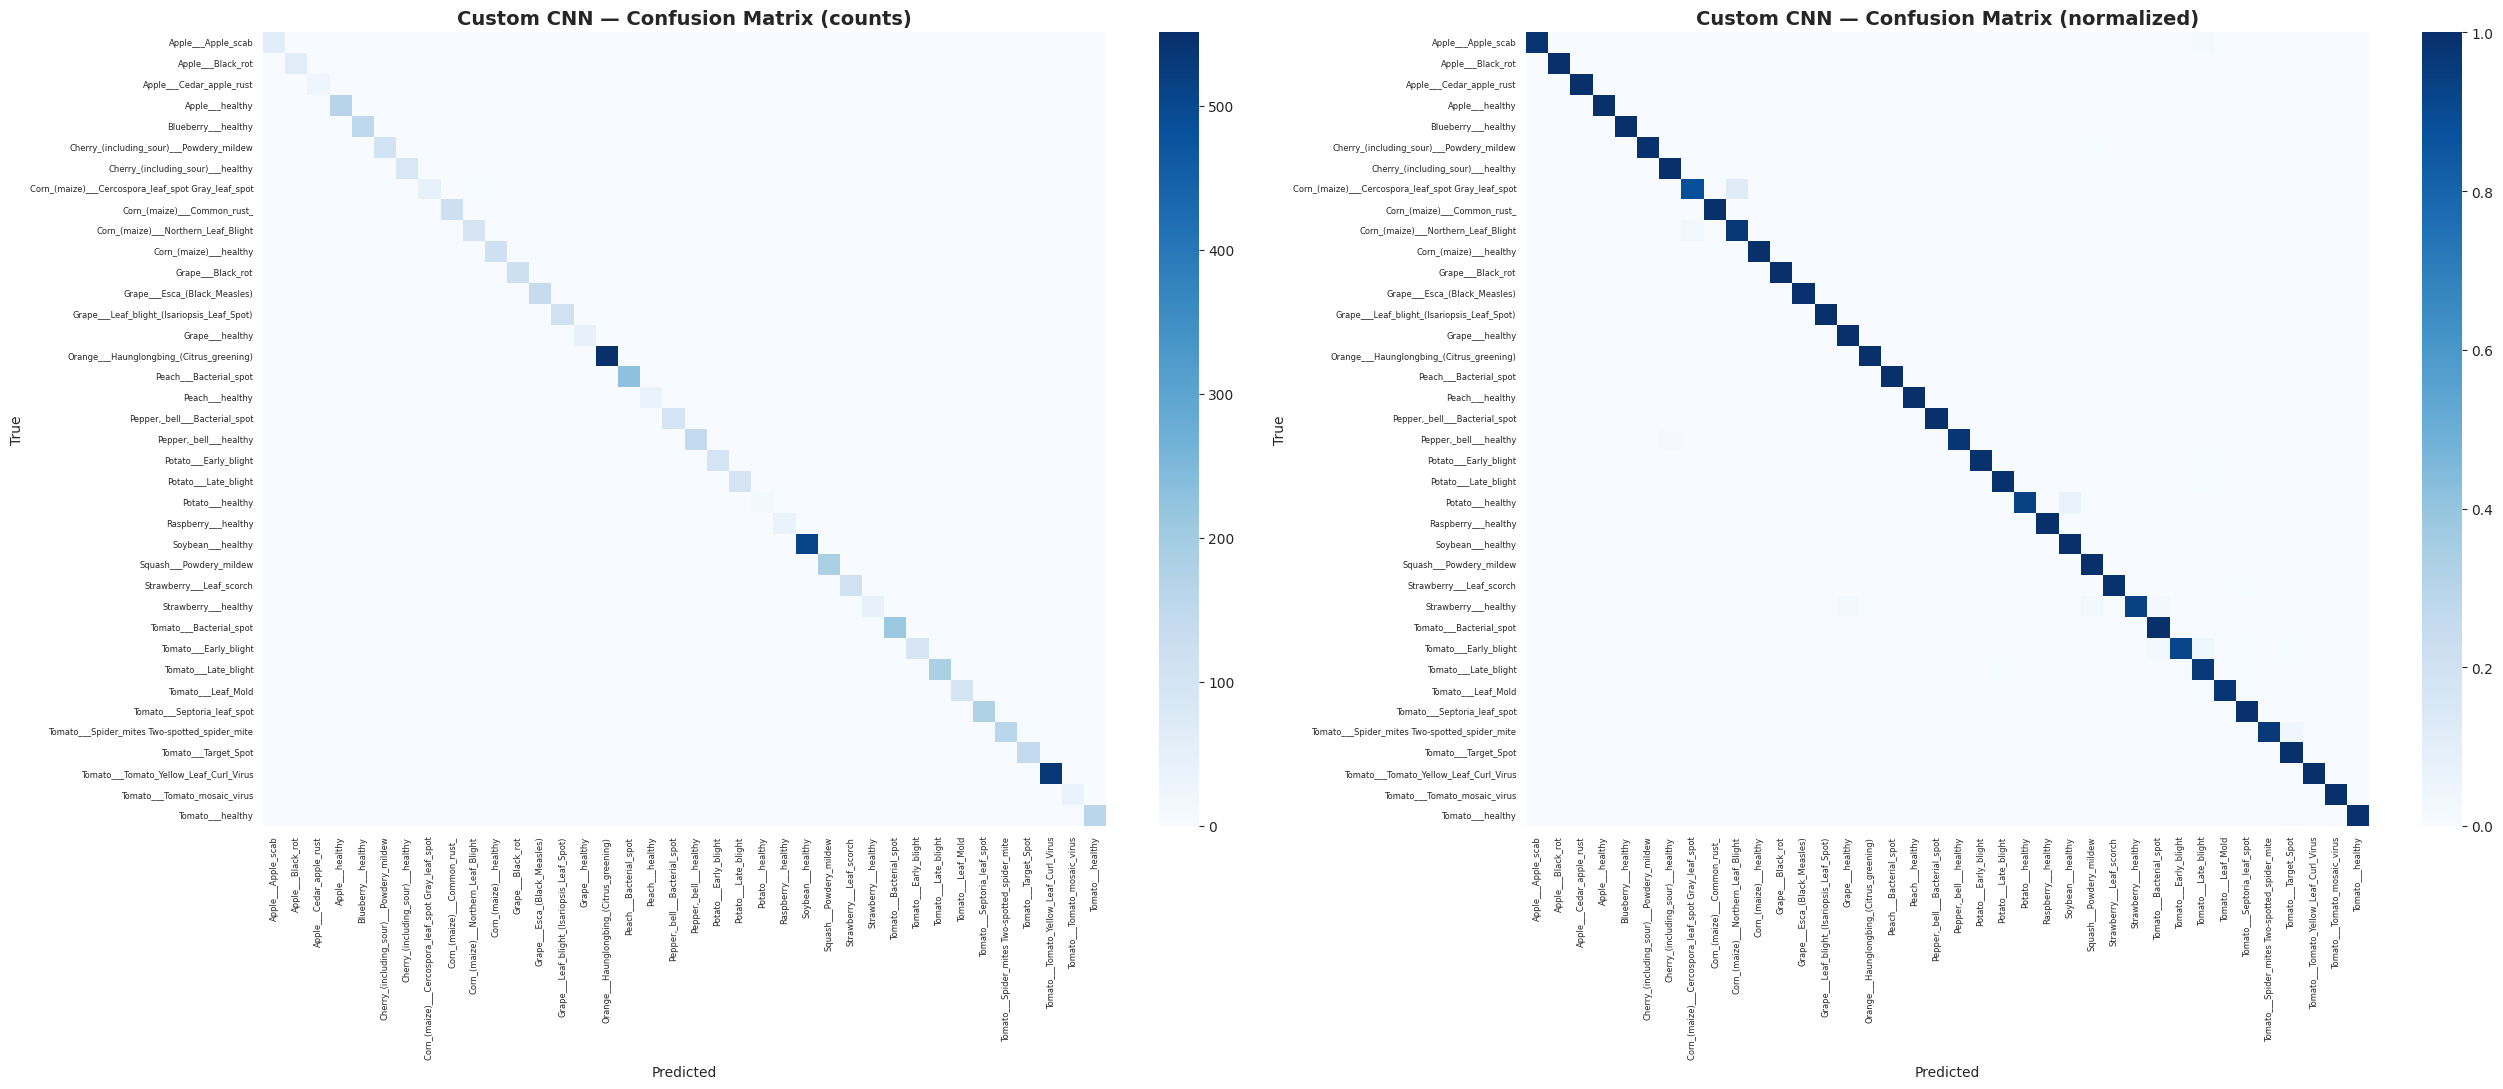


🔍 Top 10 most-confused class pairs:
     6× true=Tomato___Spider_mites Two-spotted_spider_mite predicted as Tomato___Target_Spot
     6× true=Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot predicted as Corn_(maize)___Northern_Leaf_Blight
     4× true=Tomato___Early_blight                    predicted as Tomato___Late_blight
     3× true=Corn_(maize)___Northern_Leaf_Blight      predicted as Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
     2× true=Tomato___Late_blight                     predicted as Tomato___Septoria_leaf_spot
     2× true=Tomato___Late_blight                     predicted as Potato___Late_blight
     2× true=Tomato___Early_blight                    predicted as Tomato___Bacterial_spot
     2× true=Pepper,_bell___healthy                   predicted as Cherry_(including_sour)___healthy
     1× true=Tomato___healthy                         predicted as Tomato___Target_Spot
     1× true=Tomato___Tomato_Yellow_Leaf_Curl_Virus   predicted as Tomato___Bacterial_sp

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import os, json, time

PROJECT_DIR = '/content/drive/MyDrive/PlantDiseaseProject'
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
METRICS_DIR = os.path.join(RESULTS_DIR, 'metrics')
FIG_DIR = os.path.join(RESULTS_DIR, 'figures')

# Load the best saved model
model = tf.keras.models.load_model(os.path.join(MODELS_DIR, 'custom_cnn.keras'))

# Load test set
train_ds, val_ds, test_ds, class_to_idx = get_all_datasets()
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]

# --- Inference ---
t0 = time.time()
y_pred_probs = model.predict(test_ds, verbose=1)
inference_time = time.time() - t0

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

test_acc = (y_pred == y_true).mean()
print(f"\n🎯 TEST Accuracy: {test_acc*100:.2f}%")
print(f"⏱️ Inference: {inference_time:.1f}s for {len(y_true):,} images "
      f"({inference_time/len(y_true)*1000:.2f} ms/image)")

# --- Classification report ---
print("\n" + classification_report(y_true, y_pred, target_names=class_names,
                                    zero_division=0))

report = classification_report(y_true, y_pred, target_names=class_names,
                                output_dict=True, zero_division=0)

# --- Save metrics JSON ---
metrics = {
    'model_name': 'Custom CNN',
    'test_accuracy': float(test_acc),
    'macro_f1': float(report['macro avg']['f1-score']),
    'weighted_f1': float(report['weighted avg']['f1-score']),
    'macro_precision': float(report['macro avg']['precision']),
    'macro_recall': float(report['macro avg']['recall']),
    'total_params': int(model.count_params()),
    'inference_time_sec': float(inference_time),
    'inference_ms_per_image': float(inference_time/len(y_true)*1000),
    'test_samples': int(len(y_true)),
    'per_class': {cls: {
        'precision': float(report[cls]['precision']),
        'recall':    float(report[cls]['recall']),
        'f1':        float(report[cls]['f1-score']),
        'support':   int(report[cls]['support']),
    } for cls in class_names}
}
with open(os.path.join(METRICS_DIR, 'custom_cnn_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

# --- Confusion matrices (counts + normalized) ---
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(26, 11))
sns.heatmap(cm, ax=axes[0], cmap='Blues', cbar=True,
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Custom CNN — Confusion Matrix (counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='both', labelsize=6)
plt.setp(axes[0].get_xticklabels(), rotation=90)

sns.heatmap(cm_norm, ax=axes[1], cmap='Blues', cbar=True, vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Custom CNN — Confusion Matrix (normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='both', labelsize=6)
plt.setp(axes[1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'custom_cnn_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Which classes are most confused? ---
print("\n🔍 Top 10 most-confused class pairs:")
confusions = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confusions.append((cm[i, j], class_names[i], class_names[j]))
confusions.sort(reverse=True)
for count, true_c, pred_c in confusions[:10]:
    print(f"  {count:>4}× true={true_c:<40} predicted as {pred_c}")

print(f"\n✅ Saved:")
print(f"   {METRICS_DIR}/custom_cnn_metrics.json")
print(f"   {FIG_DIR}/custom_cnn_confusion_matrix.png")